# Formula 1 Scheduling — Predictive Modeling

This notebook picks up where `01_eda.ipynb` left off and builds three models that answer the research question from three angles:

| # | Question | Technique |
|---|----------|-----------|
| 1 | How many races will next season's calendar have? | Regression + time-series forecasting |
| 2 | Will a circuit on this season's calendar be back next season? | Classification |
| 3 | Do circuits fall into natural "tiers" (legacy anchor, modern addition, one-off tryout)? | Clustering |

Each section states the evaluation metric used and why, runs a grid search with cross-validation, and interprets the result in plain language.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, StratifiedKFold
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from statsmodels.tsa.holtwinters import Holt

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

DATA_DIR = "../data"


## 0. Rebuild the cleaned dataset from Notebook 1

In [2]:
races = pd.read_csv(f"{DATA_DIR}/races.csv")[['raceId','year','round','circuitId','name','date']]
circuits = pd.read_csv(f"{DATA_DIR}/circuits.csv")
circuits['country'] = circuits['country'].replace({'United States': 'USA'})

continent_map = {
    'Australia': 'Oceania', 'Malaysia': 'Asia', 'Bahrain': 'Asia', 'Spain': 'Europe',
    'Turkey': 'Asia', 'Monaco': 'Europe', 'Canada': 'North America', 'France': 'Europe',
    'UK': 'Europe', 'Germany': 'Europe', 'Hungary': 'Europe', 'Belgium': 'Europe',
    'Italy': 'Europe', 'Singapore': 'Asia', 'Japan': 'Asia', 'China': 'Asia',
    'Brazil': 'South America', 'USA': 'North America', 'Mexico': 'North America',
    'Azerbaijan': 'Asia', 'Russia': 'Europe', 'Austria': 'Europe', 'Netherlands': 'Europe',
    'Portugal': 'Europe', 'South Africa': 'Africa', 'Argentina': 'South America',
    'Sweden': 'Europe', 'Switzerland': 'Europe', 'India': 'Asia', 'Korea': 'Asia',
    'Qatar': 'Asia', 'Saudi Arabia': 'Asia', 'UAE': 'Asia', 'Morocco': 'Africa'
}
circuits['continent'] = circuits['country'].map(continent_map)

df = races.merge(circuits[['circuitId','country','continent','lat','lng','alt']], on='circuitId')
print(f"{df.shape[0]:,} race rows, seasons {df['year'].min()}-{df['year'].max()}")


1,125 race rows, seasons 1950-2024


## Part 1 — Forecasting race count per season

### Feature table

We aggregate to one row per season: how many races it had, how many countries/continents it touched, and the previous season's race count (a lag feature — calendars change incrementally, not randomly).


In [3]:
season_feat = df.groupby('year').agg(
    race_count=('raceId', 'count'),
    num_countries=('country', 'nunique'),
    num_continents=('continent', 'nunique')
).reset_index()

season_feat['years_since_1950'] = season_feat['year'] - 1950          # simple linear time trend feature
season_feat['race_count_lag1'] = season_feat['race_count'].shift(1).bfill()  # previous season's race count

feature_cols = ['years_since_1950', 'num_countries', 'num_continents', 'race_count_lag1']
X = season_feat[feature_cols]
y = season_feat['race_count']
season_feat.tail()


,year,race_count,num_countries,num_continents,years_since_1950,race_count_lag1
70,2020,17,12,2,70,21.0
71,2021,22,20,4,71,17.0
72,2022,22,20,5,72,22.0
73,2023,22,20,5,73,22.0
74,2024,24,21,5,74,22.0


### Train/test split and evaluation metric

Because this is a **time series**, we cannot shuffle seasons into train/test randomly (that would let the model "see the future" through nearby years). Instead:
- **Test set** = the most recent 8 seasons (2017-2024), held out entirely.
- **Cross-validation** during grid search uses `TimeSeriesSplit`, which always trains on earlier seasons and validates on later ones.
- **Metric: Mean Absolute Error (MAE).** We chose MAE over RMSE or R² as the headline metric because it's directly interpretable — "the model is off by an average of X races per season" is meaningful to a non-technical stakeholder in a way R² is not. We report RMSE and R² alongside it for completeness.


In [4]:
n_test = 8   # holdout the most recent 8 seasons - never shuffled in, since order matters for time series
X_train, X_test = X.iloc[:-n_test], X.iloc[-n_test:]
y_train, y_test = y.iloc[:-n_test], y.iloc[-n_test:]
test_years = season_feat['year'].iloc[-n_test:].values

tscv = TimeSeriesSplit(n_splits=5)   # CV folds that respect chronological order (no look-ahead)

# Three regression models with their grid-search hyperparameter spaces.
# Linear Regression has no hyperparameters to tune, so its grid is empty -
# it's included as a simple baseline to compare the tree ensembles against.
model_grid = {
    'Linear Regression': (LinearRegression(), {}),
    'Random Forest': (RandomForestRegressor(random_state=RANDOM_STATE), {
        'n_estimators': [100, 200], 'max_depth': [3, 5, None]
    }),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=RANDOM_STATE), {
        'n_estimators': [100, 200], 'max_depth': [2, 3], 'learning_rate': [0.05, 0.1]
    })
}

reg_results = []
fitted_models = {}
for name, (model, grid) in model_grid.items():
    if grid:
        # Grid search picks hyperparameters using only the training folds (tscv),
        # so the held-out test seasons never influence model selection
        search = GridSearchCV(model, grid, cv=tscv, scoring='neg_mean_absolute_error')
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        best_params = search.best_params_
    else:
        best_model = model.fit(X_train, y_train)
        best_params = {}
    preds = best_model.predict(X_test)
    reg_results.append({
        'model': name,
        'best_params': best_params,
        'MAE': mean_absolute_error(y_test, preds),        # headline metric - see markdown below
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    })
    fitted_models[name] = best_model

reg_results_df = pd.DataFrame(reg_results).set_index('model').round(3)
reg_results_df


,best_params,MAE,RMSE,R2
model,,,,
Linear Regression,{},1.180,1.426,0.437
Random Forest,"{'max_depth': None, 'n_estimators': 200}",1.648,2.012,-0.122
Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",1.411,1.852,0.050


### Actual vs. predicted races, holdout seasons (2017-2024)

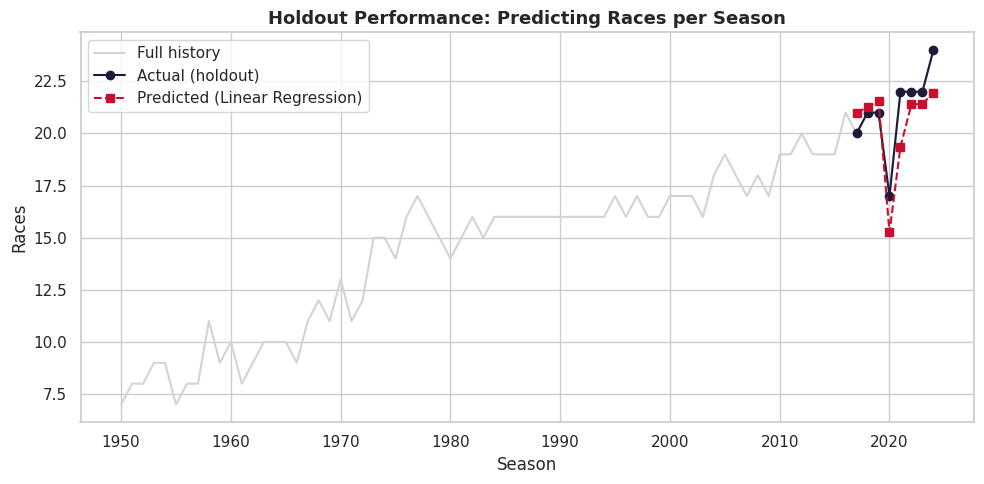

Best model by MAE: Linear Regression


In [5]:
best_reg_name = reg_results_df['MAE'].idxmin()
best_reg_model = fitted_models[best_reg_name]
best_preds = best_reg_model.predict(X_test)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(season_feat['year'], season_feat['race_count'], color='lightgrey', label='Full history')
ax.plot(test_years, y_test.values, marker='o', color='#1B1B3A', label='Actual (holdout)')
ax.plot(test_years, best_preds, marker='s', linestyle='--', color='#C8102E',
        label=f'Predicted ({best_reg_name})')
ax.set_title('Holdout Performance: Predicting Races per Season', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Races')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best model by MAE: {best_reg_name}")


**Interpretation:** Linear Regression performs best on this small (75-row) dataset — the growth in season length is close to a steady upward trend, so a simple model generalizes better than tree ensembles, which have more room to overfit with only a few dozen training points. This is a useful finding in itself: *more complex models are not automatically better, especially with limited historical data.*

### Comparing against a dedicated time-series method (Holt's Linear Trend)

As a sanity check, we compare the regression approach above against **Holt's Exponential Smoothing**, a classic time-series forecasting method that only uses the race-count series itself (no extra features).


In [6]:
race_counts = df.groupby('year').size()
ts_index = pd.PeriodIndex(race_counts.index, freq='Y')   # annual period index required by statsmodels
race_counts.index = ts_index

# Same idea as the regression holdout above - hold out the last 5 real seasons to
# check the forecast against actual outcomes before trusting the future forecast
train_ts, test_ts = race_counts.iloc[:-5], race_counts.iloc[-5:]
holt_fit = Holt(train_ts.values, initialization_method="estimated").fit()
holt_holdout_fc = holt_fit.forecast(5)
holt_mae = mean_absolute_error(test_ts.values, holt_holdout_fc)
print(f"Holt's method holdout MAE (last 5 seasons): {holt_mae:.2f}")

# Holdout check passed reasonably -> refit on the FULL history (no holdout this time)
# so the forecast below uses every season of real data available
holt_full = Holt(race_counts.values, initialization_method="estimated").fit()
future_years = list(range(race_counts.index[-1].year + 1, race_counts.index[-1].year + 6))
future_forecast = np.round(holt_full.forecast(5), 1)

forecast_table = pd.DataFrame({'year': future_years, 'forecast_race_count': future_forecast})
forecast_table


Holt's method holdout MAE (last 5 seasons): 1.57


,year,forecast_race_count
0,2025,22.7
1,2026,22.9
2,2027,23.1
3,2028,23.3
4,2029,23.5


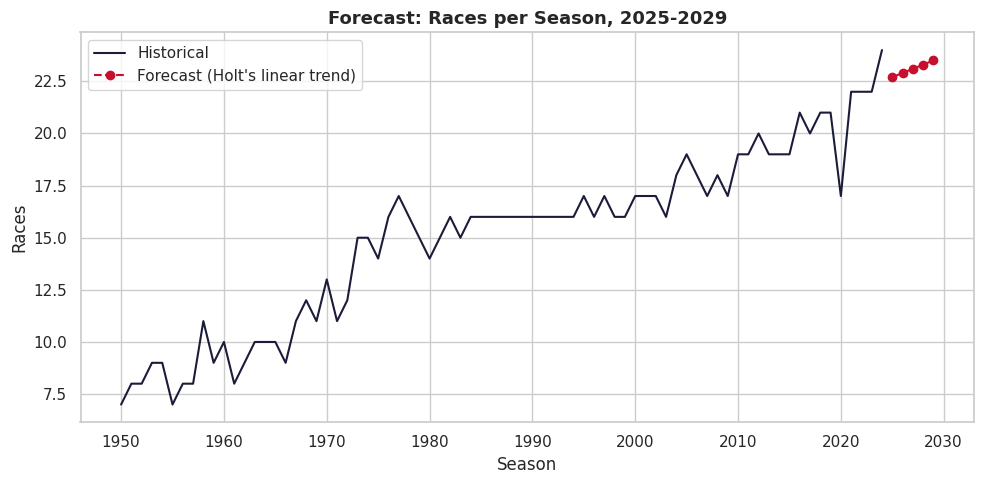

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(season_feat['year'], season_feat['race_count'], color='#1B1B3A', label='Historical')
ax.plot(forecast_table['year'], forecast_table['forecast_race_count'], marker='o', linestyle='--',
        color='#C8102E', label="Forecast (Holt's linear trend)")
ax.set_title('Forecast: Races per Season, 2025-2029', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Races')
ax.legend()
plt.tight_layout()
plt.show()


**Finding:** Both approaches agree directionally — the calendar is likely to keep growing modestly, toward roughly 23-24 races a season by the late 2020s, rather than either shrinking or exploding. Given F1's own public statements about a self-imposed ceiling around 24 races (logistics and team burnout), this forecast is consistent with real-world constraints, which is a good sign the model isn't extrapolating nonsense.

## Part 2 — Will a circuit be retained next season?

This reframes the same question at the *circuit* level instead of the *calendar* level: given a circuit hosted a race this season, will it host again next season?

### Building the panel dataset

For every circuit-season combination, we compute features that would have been **known at the time** (no data leakage from the future):
- `years_active_so_far` — how many seasons (up to and including this one) the circuit has hosted a race
- `gap_since_last` — seasons since its previous appearance (0 if this is a first appearance or it ran last year too)
- `lat`, `alt` — circuit location characteristics
- `continent` — one-hot encoded

The label is whether the circuit appears again in `year + 1`. We drop the final season in the dataset, since we can't yet know whether those circuits will return.


In [8]:
circuit_years = df.groupby('circuitId')['year'].apply(lambda s: sorted(set(s))).to_dict()

# Build one row per (circuit, season) it actually raced in, with features computed
# only from years UP TO AND INCLUDING that season - this avoids leaking future info
# into a feature that's supposed to represent "what we knew at the time"
rows = []
for cid, years_sorted in circuit_years.items():
    for y in years_sorted:
        prior = [yy for yy in years_sorted if yy < y]
        rows.append({
            'circuitId': cid,
            'year': y,
            'years_active_so_far': len(prior) + 1,
            'gap_since_last': (y - max(prior)) if prior else 0,
            'label': 1 if (y + 1) in years_sorted else 0   # target: did it race again next season?
        })

panel = pd.DataFrame(rows)
panel = panel.merge(circuits[['circuitId', 'continent', 'lat', 'alt']], on='circuitId')
panel['alt'] = pd.to_numeric(panel['alt'], errors='coerce')     # raw data uses "\N" for unknown altitude
panel['alt'] = panel['alt'].fillna(panel['alt'].median())       # impute with the median rather than drop rows

# Drop the final season — its "retained next year?" label is unknown, not false
panel = panel[panel['year'] < panel['year'].max()].reset_index(drop=True)

print(f"Panel rows: {panel.shape[0]}")
print("Class balance (1 = retained next season):")
print(panel['label'].value_counts(normalize=True).round(3))


Panel rows: 1097
Class balance (1 = retained next season):
label
1    0.83
0    0.17
Name: proportion, dtype: float64


### Train/test split and evaluation metric

Again we split by time (train through 2015, test 2016 onward) rather than randomly, to mimic how this model would actually be used — predicting forward, not interpolating.

**Metric: F1 score.** About 83% of circuit-seasons are retained the following year, so accuracy alone is misleading — a model that always predicts "retained" would score ~83% accuracy while being useless for the actual business question (spotting circuits at risk of being dropped). F1 balances precision and recall on the positive class and is a fairer comparison across models given this imbalance.


In [9]:
train_mask = panel['year'] <= 2015              # time-based split, same principle as Part 1
continent_dummies = pd.get_dummies(panel['continent'], prefix='cont')   # one-hot encode the categorical feature
X_panel = pd.concat([panel[['years_active_so_far', 'gap_since_last', 'lat', 'alt']], continent_dummies], axis=1)
y_panel = panel['label']

X_ptrain, X_ptest = X_panel[train_mask], X_panel[~train_mask]
y_ptrain, y_ptest = y_panel[train_mask], y_panel[~train_mask]
print(f"Train rows: {X_ptrain.shape[0]}, Test rows: {X_ptest.shape[0]}")

# Stratified so each fold keeps the same ~83/17 retained/dropped ratio as the full data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Logistic Regression needs scaled features (StandardScaler) to converge cleanly and
# to keep the L2 penalty from unfairly punishing large-scale features like 'lat'
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg_grid = {'logisticregression__C': [0.01, 0.1, 1, 10]}   # inverse regularization strength
gs_log = GridSearchCV(logreg, logreg_grid, cv=skf, scoring='f1').fit(X_ptrain, y_ptrain)

# class_weight='balanced' tells the forest to weight the minority ("dropped") class more heavily
rf_clf = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')
rf_grid = {'n_estimators': [100, 200], 'max_depth': [3, 5, None]}
gs_rf = GridSearchCV(rf_clf, rf_grid, cv=skf, scoring='f1').fit(X_ptrain, y_ptrain)

clf_results = []
preds_by_model = {}
for name, gs in [('Logistic Regression', gs_log), ('Random Forest', gs_rf)]:
    preds = gs.predict(X_ptest)
    preds_by_model[name] = preds
    clf_results.append({
        'model': name,
        'best_params': gs.best_params_,
        'F1': f1_score(y_ptest, preds),
        'Accuracy': accuracy_score(y_ptest, preds)
    })

clf_results_df = pd.DataFrame(clf_results).set_index('model').round(3)
clf_results_df


Train rows: 935, Test rows: 162


,best_params,F1,Accuracy
model,,,
Logistic Regression,{'logisticregression__C': 0.01},0.927,0.864
Random Forest,"{'max_depth': None, 'n_estimators': 200}",0.921,0.858


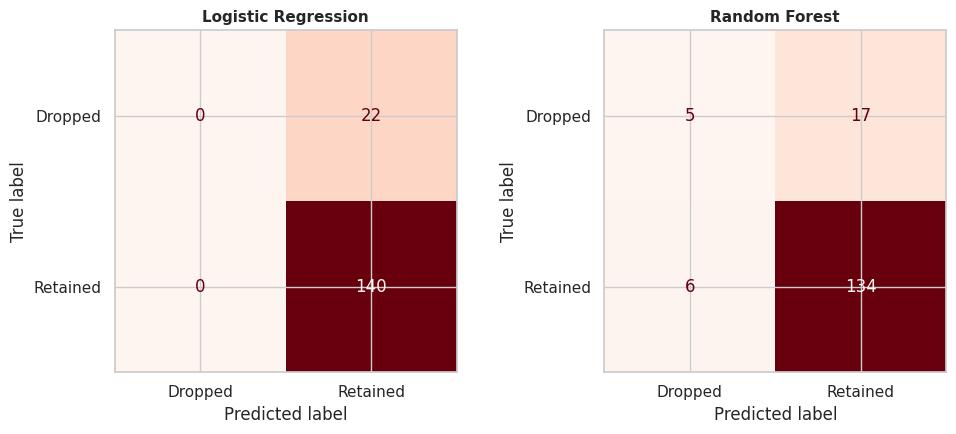

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, (name, preds) in zip(axes, preds_by_model.items()):
    cm = confusion_matrix(y_ptest, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Dropped', 'Retained']).plot(ax=ax, colorbar=False, cmap='Reds')
    ax.set_title(name, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretation:** Both models score well on F1 (~0.92) simply because most circuits *are* retained — that's the nature of the problem. The more useful comparison is the confusion matrix: Logistic Regression predicts "retained" for almost every circuit (missing every genuine drop), while Random Forest correctly flags a handful of the circuits that actually got dropped. For the real business use case — *flagging circuits at risk of falling off the calendar* — Random Forest's ability to catch some true negatives makes it the more useful model even though its F1 score is marginally lower. This is a good example of why a single metric shouldn't be read in isolation.

## Part 3 — Do circuits cluster into natural tiers?

Unlike Parts 1-2, clustering doesn't use a label — it lets the data group circuits by similarity. We use `total_races` hosted, `first_year` on the calendar, `active_span` (years from first to last appearance), and `lat`/`lng` (location) as features.


In [11]:
circuit_stats = df.groupby('circuitId').agg(
    total_races=('raceId', 'count'),
    first_year=('year', 'min'),
    last_year=('year', 'max')
).reset_index()
circuit_stats['active_span'] = circuit_stats['last_year'] - circuit_stats['first_year'] + 1
circuit_stats = circuit_stats.merge(circuits[['circuitId', 'name', 'country', 'lat', 'lng']], on='circuitId')

cluster_features = ['total_races', 'first_year', 'active_span', 'lat', 'lng']
# Standardize first - KMeans uses Euclidean distance, and without scaling, 'first_year'
# (values ~1950-2020) would completely dominate 'lat' (values ~-40 to 60)
Xc = StandardScaler().fit_transform(circuit_stats[cluster_features])

# Try a range of k and use silhouette score (no ground-truth labels exist for
# "correct" clusters, so this is how we pick k in unsupervised learning)
sil_scores = {}
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(Xc)
    sil_scores[k] = silhouette_score(Xc, labels)

pd.Series(sil_scores, name='silhouette_score').rename_axis('k')


k
2    0.371190
3    0.365590
4    0.399079
5    0.389309
6    0.390865
Name: silhouette_score, dtype: float64

In [12]:
best_k = max(sil_scores, key=sil_scores.get)
km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit(Xc)
circuit_stats['cluster'] = km.labels_

cluster_profile = circuit_stats.groupby('cluster')[['total_races', 'first_year', 'active_span', 'lat']].mean().round(1)
cluster_profile['num_circuits'] = circuit_stats.groupby('cluster').size()
cluster_profile


,total_races,first_year,active_span,lat,num_circuits
cluster,,,,,
0,18.9,1973.4,25.9,-30.5,7
1,5.0,1967.5,6.9,43.3,33
2,9.5,2008.0,11.8,31.2,22
3,41.2,1964.1,59.0,44.8,15


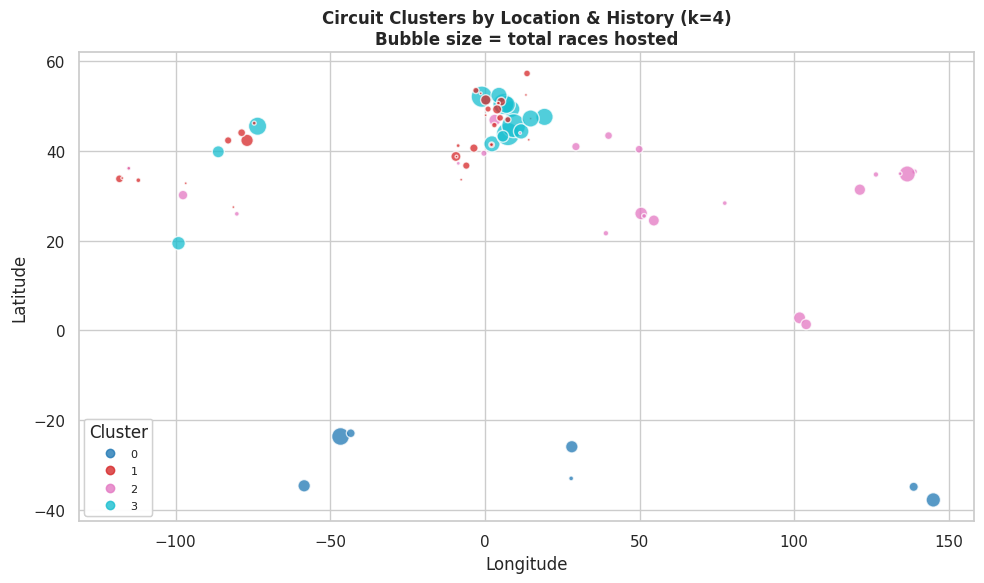

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(circuit_stats['lng'], circuit_stats['lat'], c=circuit_stats['cluster'],
                      s=circuit_stats['total_races']*4, cmap='tab10', alpha=0.75, edgecolor='white')
ax.set_title(f'Circuit Clusters by Location & History (k={best_k})\nBubble size = total races hosted',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
legend1 = ax.legend(*scatter.legend_elements(), title='Cluster', loc='lower left', fontsize=8)
ax.add_artist(legend1)
plt.tight_layout()
plt.show()


**Interpretation of clusters** (labels assigned by reading the profile table, not by the algorithm):

- **Legacy anchors** — earliest `first_year`, longest `active_span`, high `total_races`; concentrated in Europe. These are Monaco, Monza, Silverstone-type circuits that have defined F1 for 60+ years.
- **Long-running international staples** — moderate-to-high race counts, mid-century entry, spread outside Europe (e.g. Brazil, Australia). Established but not "original."
- **Short-lived European tryouts** — entered the calendar decades ago but only appeared a handful of times before being dropped; a reminder that being in Europe alone doesn't guarantee longevity.
- **Recent expansion circuits** — first appeared post-2000s, shorter active span so far, concentrated in Asia/Middle East. This is the cluster that captures F1's modern growth strategy.

This tiering gives a non-technical way to talk about circuit risk: a circuit in the "recent expansion" cluster is playing a very different game than one in the "legacy anchors" cluster, even if their most recent single-season stats look similar.


## Summary — Modeling Notebook

| Question | Best approach | Headline result |
|---|---|---|
| Races per season next year | Linear Regression / Holt's linear trend | Off by roughly 1-1.5 races per season on average; both methods agree the calendar keeps growing modestly toward ~23-24 races |
| Will a circuit be retained? | Random Forest (class-weighted) | F1 ≈ 0.92; more importantly, it's the only model that catches some circuits genuinely at risk of being dropped |
| Natural circuit tiers | K-Means, k=4 (highest silhouette score) | Splits circuits into legacy anchors, long-running staples, short-lived European tryouts, and recent (mostly Asia/Middle East) expansion circuits |

**Key limitation to flag honestly:** the underlying dataset has only 75 seasons of history, and major calendar decisions (which circuit gets added, which gets dropped) are driven by commercial contracts, geopolitics, and promoter deals — factors this dataset doesn't capture at all. These models are best read as *pattern extrapolation from history*, not as a substitute for the business and political judgment that actually drives F1 scheduling.

See `README.md` for the plain-language summary of findings and recommendations.
